# Simulation_CLP_PID_FF

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_LAB
import package_DBR
from package_DBR import SelectPath_RT, Delay_RT, FO_RT
from package_LAB import LL_RT, PID_RT, IMC_Tuning, Margin

In [162]:
Kp = 0.36
Tp1 = 170.82
Tp2 = 26.55
thetap = 13.31

Kd = 0.31
Td1 = 161.20
Td2 = 32.3
thetad = 15.75

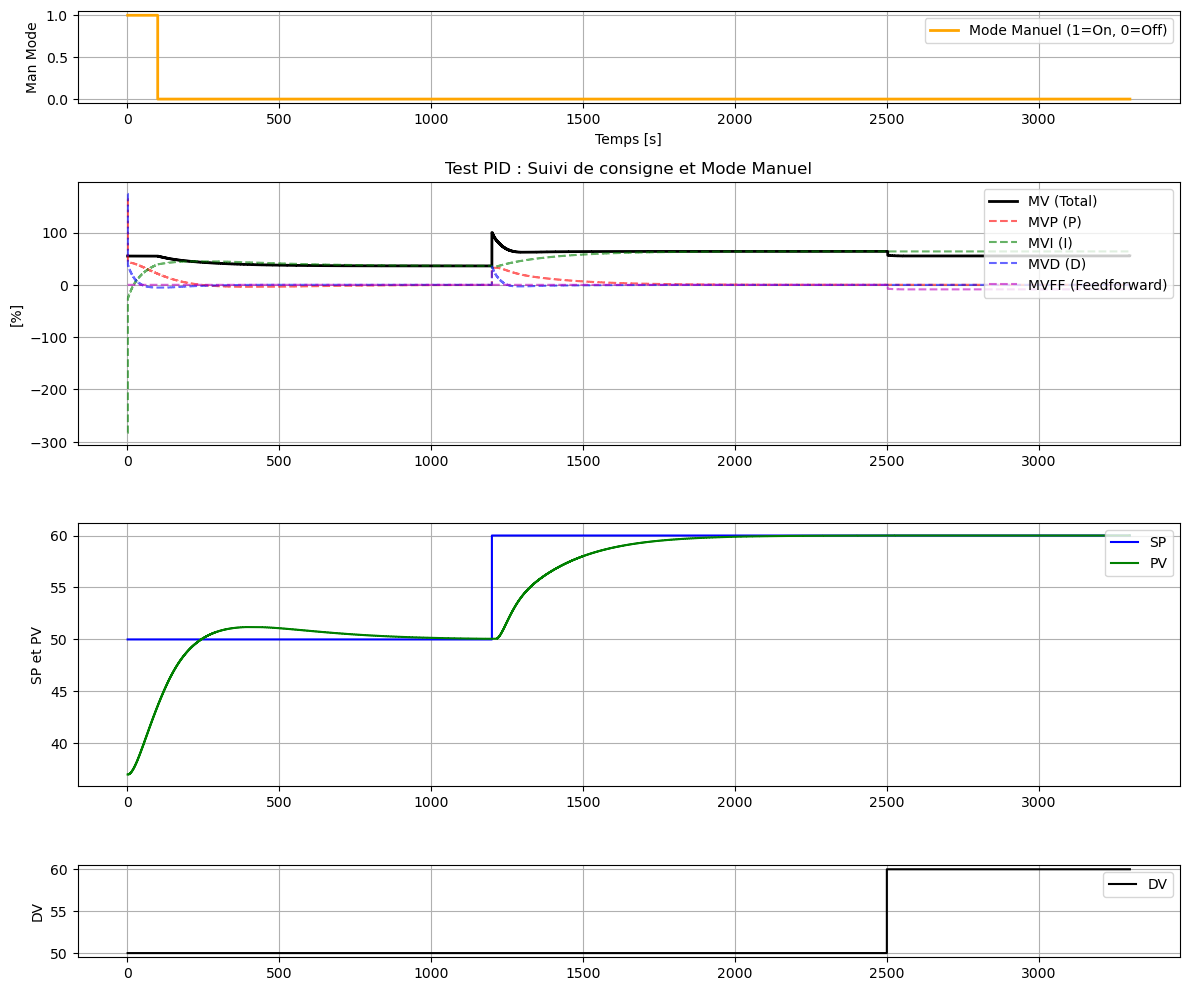

PID Tuning : Kc=3.28, Ti=197.37, Td=22.98, Td/Ti=0.12
Dernières valeurs : P=0.00, I=63.89, D=-0.00, FF=-8.61


In [163]:
TSim = 3300
Ts = 1 
N = int(TSim/Ts) + 1

#Parametres
PV0 = 55
MV0= 50
DV0 = 50
K_FF = -Kd / Kp
theta_FF = max(0, thetad - thetap)

alpha = 0.9
gamma = 0.9
Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2= Tp2, tauc=gamma*Tp1 , model='SOPDT')
MVMin = 0
MVMax = 100
booléan = True


t = []
DV = []

#FEEDFORWARD
DV_delta = []
DV_delay = []
MVFF_step1 = [] 
MVFF = []

#PID
E = []
SP = []
Man = []
MVMan = []
MV = []
MVP = [] 
MVI = [] 
MVD = []

#PROCESS
MVDelayp = []
PV1p = []
PV2p = []
PV = []

#D(s)
MVDelayd = []
PV1d = []
PV2d = []


DVPath = {0: 50, 2500: 60, TSim: 60}
SPPath = {0: 50, 1200: 60, TSim: 60}
ManPath = {0: True, 100: False, 1500: False, TSim: False}
#ManPath = {0: True, TSim: True}
MVManPath = {0: 55, TSim: 55}

for i in range(1, N):

    t.append(i * Ts)

    SelectPath_RT(DVPath, t, DV)
    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(ManPath, t, Man)
    SelectPath_RT(MVManPath, t, MVMan) 
    
    #LL
    DV_delta.append(DV[-1] - DV0)
    Delay_RT(DV_delta, theta_FF, Ts, DV_delay)
    LL_RT(DV_delay, K_FF, Tp1, Td1, Ts, MVFF_step1, method='EBD')
    if booléan == True:
        LL_RT(MVFF_step1, 1.0, Tp2, Td2, Ts, MVFF, method='EBD')
    else:
        LL_RT(MVFF_step1, 0, Tp2, Td2, Ts, MVFF, method='EBD')
        
    #PID
    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF = booléan)

    #P(s)
    Delay_RT(MV, thetap, Ts, MVDelayp, MV0)
    FO_RT(MVDelayp, Kp, Tp1, Ts, PV1p)
    FO_RT(PV1p, 1, Tp2, Ts, PV2p)
   
    #D(s)
    Delay_RT(DV_delta, thetad, Ts, MVDelayd)
    FO_RT(MVDelayd, Kd, Td1, Ts, PV1d)
    FO_RT(PV1d, 1, Td2, Ts, PV2d)

    PV.append(PV2p[-1] + PV2d[-1] + PV0-Kp*MV0)


plt.figure(figsize=(12, 10))

#MV
ax2 = plt.subplot2grid((12, 1), (2, 0), rowspan=4)
ax2.step(t, MV, 'k-', lw=2, label='MV (Total)', where='post')
ax2.step(t, MVP, 'r--', label='MVP (P)', where='post', alpha=0.6)
ax2.step(t, MVI, 'g--', label='MVI (I)', where='post', alpha=0.6)
ax2.step(t, MVD, 'b--', label='MVD (D)', where='post', alpha=0.6)
ax2.step(t, MVFF, 'm--', label='MVFF (Feedforward)', where='post', alpha=0.6)
ax2.set_ylabel('[%]')
ax2.set_title('Test PID : Suivi de consigne et Mode Manuel')
ax2.legend(loc='upper right')
ax2.grid(True)

#SP, PV
ax3 = plt.subplot2grid((12, 1), (6, 0), rowspan=4)
ax3.step(t, SP, 'b-', label='SP', where='post')
ax3.step(t, PV, 'g-', label='PV', where='post')
#ax3.step(t, E, 'r-', label='Erreur', where='post')
ax3.set_ylabel('SP et PV')
ax3.legend(loc='upper right')
ax3.grid(True)

#DV
ax4 = plt.subplot2grid((12, 1), (10, 0), rowspan=2)
ax4.step(t, DV, 'k-', label='DV', where='post')
ax4.set_ylabel('DV')
ax4.legend(loc='upper right')
ax4.grid(True)
 

#Mode Manuel
ax1 = plt.subplot2grid((12, 1), (0, 0), rowspan=2)
ax1.step(t, [int(m) for m in Man], 'orange', lw=2, label='Mode Manuel (1=On, 0=Off)', where='post')
ax1.set_ylabel('Man Mode')
ax1.set_xlabel('Temps [s]')
ax1.legend(loc='upper right')
ax1.grid(True)


plt.tight_layout()
plt.show()


print(f"PID Tuning : Kc={Kc:.2f}, Ti={Ti:.2f}, Td={Td:.2f}, Td/Ti={Td/Ti:.2f}")
print(f"Dernières valeurs : P={MVP[-1]:.2f}, I={MVI[-1]:.2f}, D={MVD[-1]:.2f}, FF={MVFF[-1]:.2f}")


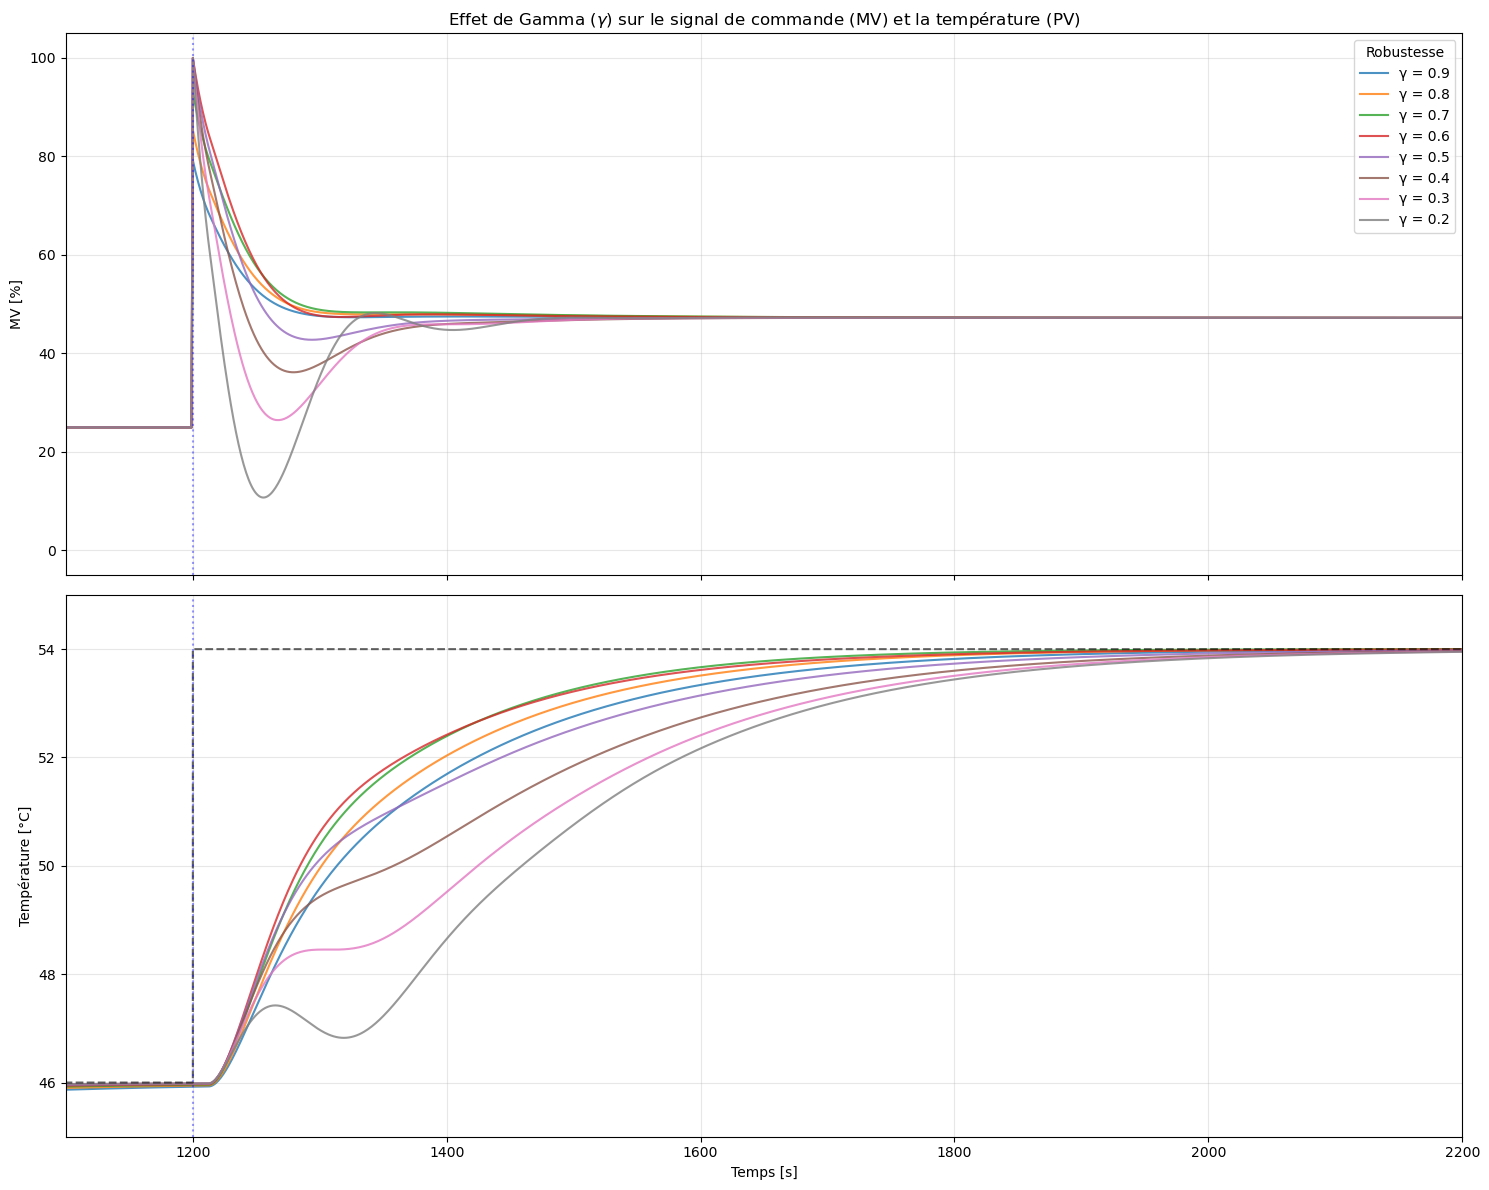

In [164]:
gammas = np.arange(0.9, 0.1, -0.1) # 0.9, 0.8, ..., 0.2
TSim = 3300
Ts = 1 
N = int(TSim/Ts) + 1

# Création de la figure avec deux sous-graphiques
fig, (ax_mv, ax_pv) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

for g in gammas:
    # 1. Calcul du Tuning pour ce gamma
    tauc = g * Tp1
    Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2=Tp2, tauc=tauc, model='SOPDT')
    
    # 2. Initialisation (Reset des vecteurs pour chaque gamma)
    t, PV, MV = [], [], []
    PV1p, PV2p, MVDelayp = [0], [0], []
    PV1d, PV2d, MVDelayd = [0], [0], []
    DV, SP, Man, MVMan = [], [], [], []
    DV_delta, DV_delay, MVFF_step1, MVFF = [], [], [], []
    E, MVP, MVI, MVD = [], [], [], []

    # Chemins
    DVPath = {0: 50, 2500: 60, TSim: 60}
    SPPath = {0: 46, 1200: 54, TSim: 55}
    ManPath = {0: False, TSim: False}
    MVManPath = {0: 50, TSim: 50}

    # 3. Boucle de simulation
    for i in range(1, N):
        curr_t = i * Ts
        t.append(curr_t)
        
        SelectPath_RT(DVPath, t, DV)
        SelectPath_RT(SPPath, t, SP)
        SelectPath_RT(ManPath, t, Man)
        SelectPath_RT(MVManPath, t, MVMan)
        
        # Feedforward (activé ici)
        DV_delta.append(DV[-1] - DV0)
        Delay_RT(DV_delta, theta_FF, Ts, DV_delay)
        LL_RT(DV_delay, K_FF, Tp1, Td1, Ts, MVFF_step1)
        LL_RT(MVFF_step1, 1.0, Tp2, Td2, Ts, MVFF)
        
        # PID
        PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, 0.9, Ts, 0, 100, MV, MVP, MVI, MVD, E, ManFF=True)
        
        # Procédé
        Delay_RT(MV, thetap, Ts, MVDelayp, MV0)
        FO_RT(MVDelayp, Kp, Tp1, Ts, PV1p)
        FO_RT(PV1p, 1, Tp2, Ts, PV2p)
        
        Delay_RT(DV_delta, thetad, Ts, MVDelayd)
        FO_RT(MVDelayd, Kd, Td1, Ts, PV1d)
        FO_RT(PV1d, 1, Td2, Ts, PV2d)
        
        PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)
    
    # 4. Tracé des courbes
    ax_mv.plot(t, MV, label=f'γ = {g:.1f}', alpha=0.8)
    ax_pv.plot(t, PV, label=f'γ = {g:.1f}', alpha=0.8)
# --- Mise en forme ---
# Graphe MV
ax_mv.set_title('Effet de Gamma ($\gamma$) sur le signal de commande (MV) et la température (PV)')
ax_mv.set_ylabel('MV [%]')
ax_mv.grid(True, alpha=0.3)
ax_mv.legend(loc='upper right', title="Robustesse")

# Graphe PV
ax_pv.step(t, SP, 'k--', label='Consigne (SP)', where='post', alpha=0.6)
ax_pv.set_ylabel('Température [°C]')
ax_pv.set_xlabel('Temps [s]')
ax_pv.set_xlim([1100, 2200])
ax_pv.set_ylim([45, 55])
ax_pv.grid(True, alpha=0.3)

# Mise en évidence des événements
for ax in [ax_mv, ax_pv]:
    ax.axvline(1200, color='blue', linestyle=':', alpha=0.4) # Saut SP
    ax.axvline(2500, color='red', linestyle=':', alpha=0.4)  # Perturbation DV

plt.tight_layout()
plt.show()

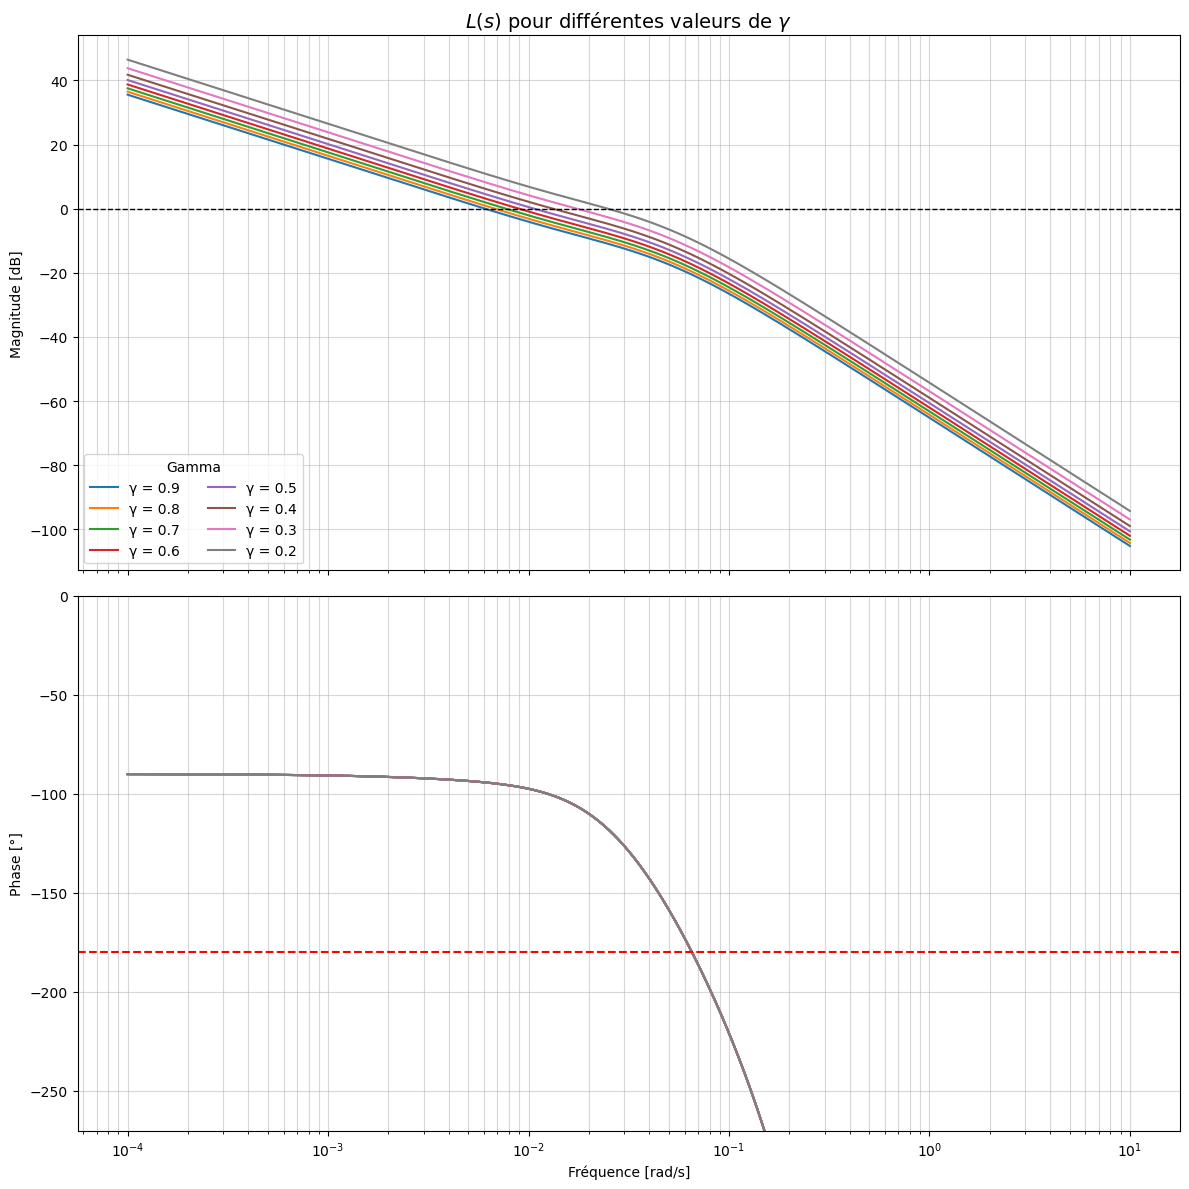

In [165]:
omega = np.logspace(-4, 1, 1000)
s = 1j * omega

# Process P(s)
P = (Kp * np.exp(-thetap * s)) / ((Tp1 * s + 1) * (Tp2 * s + 1))

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

for g in gammas:
    tauc = g * Tp1
    Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2=Tp2, tauc=tauc, model='SOPDT')
    
    # Controller C(s)
    C = Kc * (1 + 1/(Ti * s) + (Td * s) / (alpha * Td * s + 1))
    
    # Open-loop L(s)
    L = P * C
    
    mag = 20 * np.log10(np.abs(L))
    phase = np.rad2deg(np.unwrap(np.angle(L)))
    
    ax_mag.semilogx(omega, mag, label=f'γ = {g:.1f}')
    ax_phase.semilogx(omega, phase, label=f'γ = {g:.1f}')

# Formatting Magnitude
ax_mag.set_title('$L(s)$ pour différentes valeurs de $\gamma$', fontsize=14)
ax_mag.set_ylabel('Magnitude [dB]')
ax_mag.axhline(0, color='black', lw=1, linestyle='--')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)
ax_mag.legend(loc='lower left', title='Gamma', ncol=2)

# Formatting Phase
ax_phase.set_ylabel('Phase [°]')
ax_phase.set_xlabel('Fréquence [rad/s]')
ax_phase.axhline(-180, color='red', lw=1.5, linestyle='--')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)
ax_phase.set_ylim([-270, 0])

plt.tight_layout()
plt.show()

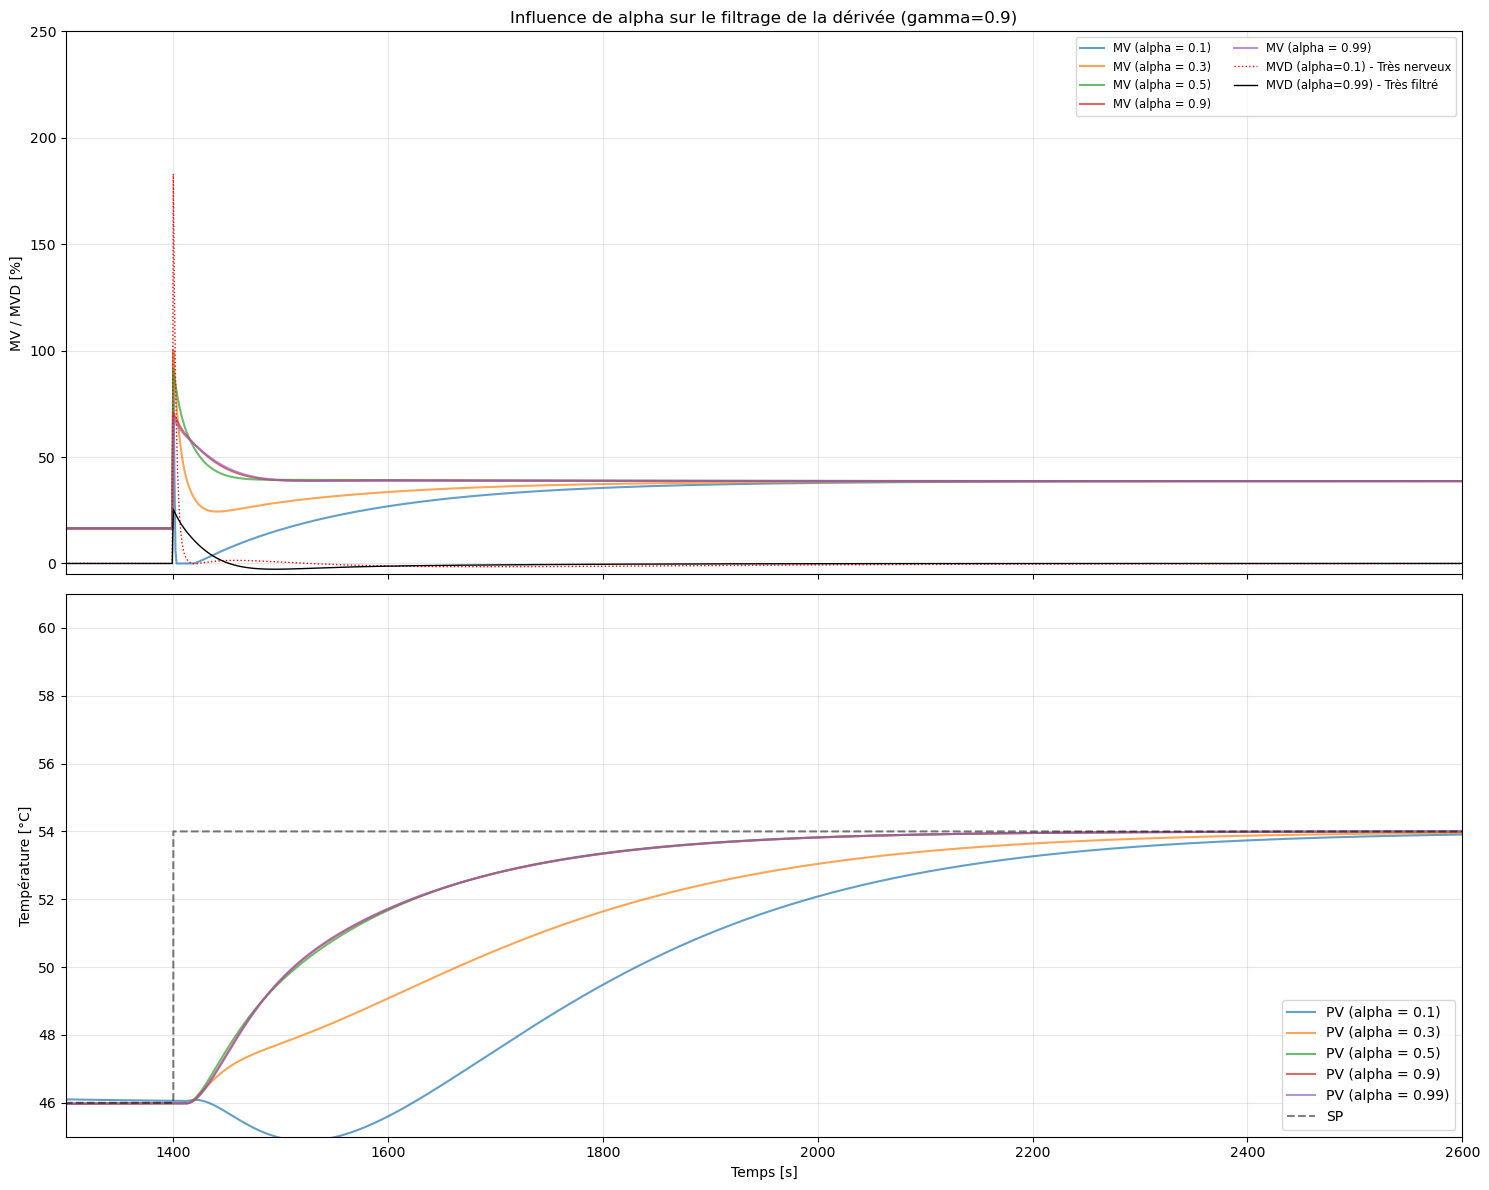

In [ ]:
alphas = [0.1, 0.3, 0.5, 0.9, 0.99]
gamma = 0.9
TSim = 3300
Ts = 1 
N = int(TSim/Ts) + 1

# On calcule le Tuning une seule fois car gamma est fixe
Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2=Tp2, tauc=gamma*Tp1, model='SOPDT')

fig, (ax_mv, ax_pv) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Pour stocker les MVD des extrêmes pour l'affichage final
mvd_min_alpha = []
mvd_max_alpha = []

for a in alphas:
    # Reset des vecteurs pour chaque simulation
    t, PV, MV, SP = [], [], [], []
    PV1p, PV2p, MVDelayp = [], [], []
    DV, Man, MVMan = [], [], []
    E, MVP, MVI, MVD = [], [], [], []
    MVFF = np.zeros(N) # On simplifie sans FF pour mieux voir l'effet alpha

    SPPath = {0: 50, 1400: 60, TSim: 60}
    ManPath = {0: False, TSim: False}

    for i in range(1, N):
        curr_t = (i-1) * Ts
        t.append(curr_t)
        SelectPath_RT(SPPath, t, SP)
        SelectPath_RT(ManPath, t, Man)
        
        # PID avec l'alpha de la boucle
        PID_RT(SP, PV, Man, [50]*N, MVFF, Kc, Ti, Td, a, Ts, 0, 100, MV, MVP, MVI, MVD, E)
        
        # Procédé
        Delay_RT(MV, thetap, Ts, MVDelayp, MV0)
        FO_RT(MVDelayp, Kp, Tp1, Ts, PV1p)
        FO_RT(PV1p, 1, Tp2, Ts, PV2p)
        PV.append(PV2p[-1] + PV2d[-1] + PV0-Kp*MV0)

    # Tracé du MV total pour chaque alpha
    ax_mv.plot(t, MV, label=f'MV (alpha = {a})', alpha=0.7)
    # Tracé du PV correspondant
    ax_pv.plot(t, PV, label=f'PV (alpha = {a})', alpha=0.7)
    
    # Sauvegarde des MVD pour les extrêmes (0.1 et 0.99)
    if a == 0.1: mvd_min_alpha = list(MVD)
    if a == 0.99: mvd_max_alpha = list(MVD)

# --- Affichage des composantes D (MVD) pour le min et le max ---
ax_mv.plot(t, mvd_min_alpha, 'r:', lw=1, label='MVD (alpha=0.1) - Très nerveux')
ax_mv.plot(t, mvd_max_alpha, 'k-', lw=1, label='MVD (alpha=0.99) - Très filtré')

# --- Mise en forme ---
ax_mv.set_title(f'Influence de alpha sur le filtrage de la dérivée (gamma={gamma})')
ax_mv.set_ylabel('MV / MVD [%]')
ax_mv.set_ylim([-5, 250])
ax_mv.legend(loc='upper right', fontsize='small', ncol=2)
ax_mv.grid(True, alpha=0.3)

ax_pv.step(t, SP, 'k--', label='SP', where='post', alpha=0.5)
ax_pv.set_ylabel('Température [°C]')
ax_pv.set_xlabel('Temps [s]')
ax_pv.set_xlim([1300, 2600])
ax_pv.set_ylim([45, 61])
ax_pv.legend(loc='lower right')
ax_pv.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

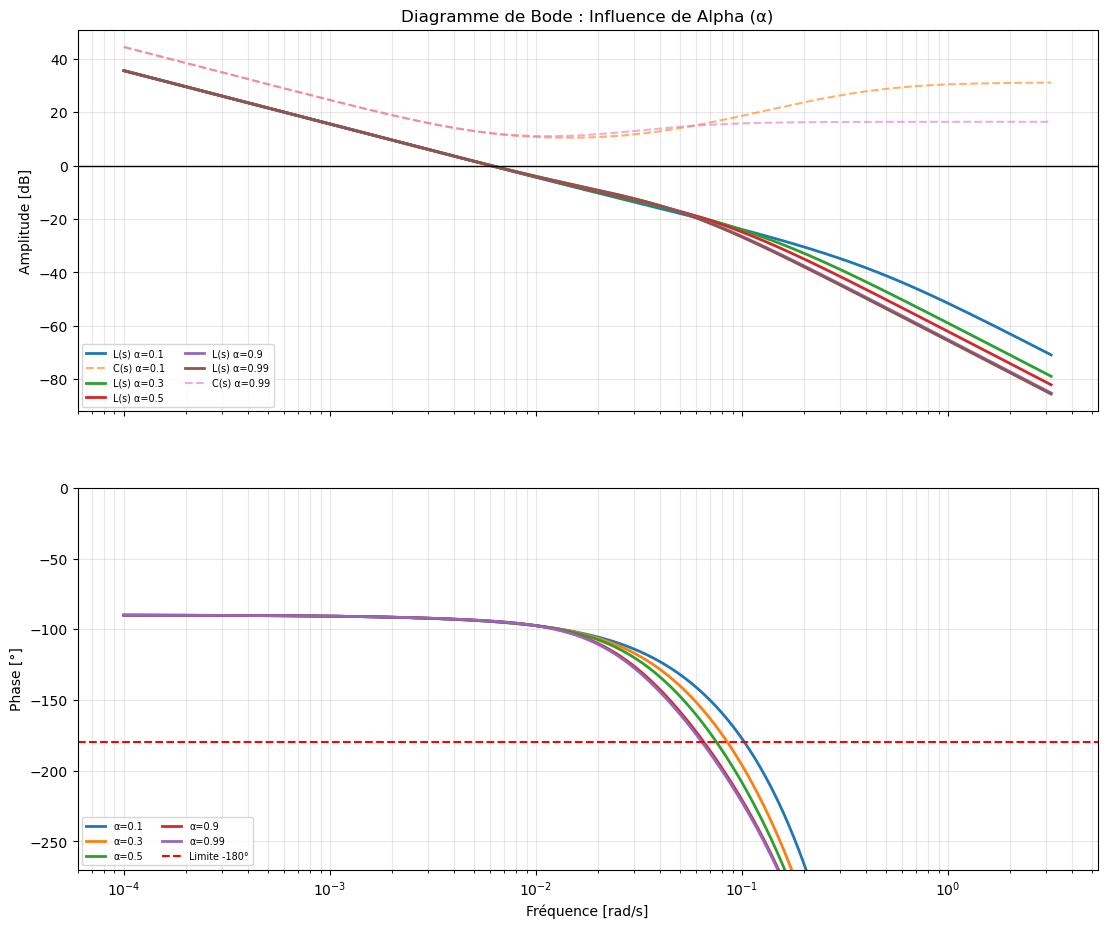

In [167]:
alphas = [0.1, 0.3, 0.5, 0.9, 0.99]
omega = np.logspace(-4, 0.5, 1000) # On s'arrête à 10^0.5 pour plus de stabilité
s = 1j * omega

# Procédé P(s)
P = (Kp * np.exp(-thetap * s)) / ((Tp1 * s + 1) * (Tp2 * s + 1))

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for a in alphas:
    # Calcul du Tuning
    Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2=Tp2, tauc=gamma*Tp1, model='SOPDT')
    
    # Contrôleur C(s) avec filtre de dérivée
    # Attention : ne pas mettre a=0 sinon division par zéro
    C = Kc * (1 + 1/(Ti * s) + (Td * s) / (max(a, 0.001) * Td * s + 1))
    L = P * C
    
    # 1. Amplitude [dB]
    mag_L = 20 * np.log10(np.abs(L))
    ax_mag.semilogx(omega, mag_L, label=f'L(s) α={a}', lw=2)
    
    if a in [0.1, 0.99]:
        mag_C = 20 * np.log10(np.abs(C))
        ax_mag.semilogx(omega, mag_C, '--', label=f'C(s) α={a}', alpha=0.6)

    # 2. Phase [°]
    phase_L = np.rad2deg(np.unwrap(np.angle(L)))
    ax_phase.semilogx(omega, phase_L, label=f'α={a}', lw=2)

# --- Mise en forme ---
ax_mag.set_title('Diagramme de Bode : Influence de Alpha (α)')
ax_mag.set_ylabel('Amplitude [dB]')
ax_mag.axhline(0, color='black', lw=1)
ax_mag.grid(True, which='both', alpha=0.3)
ax_mag.legend(loc='lower left', ncol=2, fontsize='x-small')

ax_phase.set_ylabel('Phase [°]')
ax_phase.set_xlabel('Fréquence [rad/s]')
ax_phase.axhline(-180, color='red', linestyle='--', label='Limite -180°')
ax_phase.set_ylim([-270, 0])
ax_phase.grid(True, which='both', alpha=0.3)
ax_phase.legend(loc='lower left', ncol=2, fontsize='x-small')

# Remplacement de tight_layout par une gestion manuelle des marges
plt.subplots_adjust(hspace=0.2, top=0.92, bottom=0.08, left=0.1, right=0.95)
plt.show()

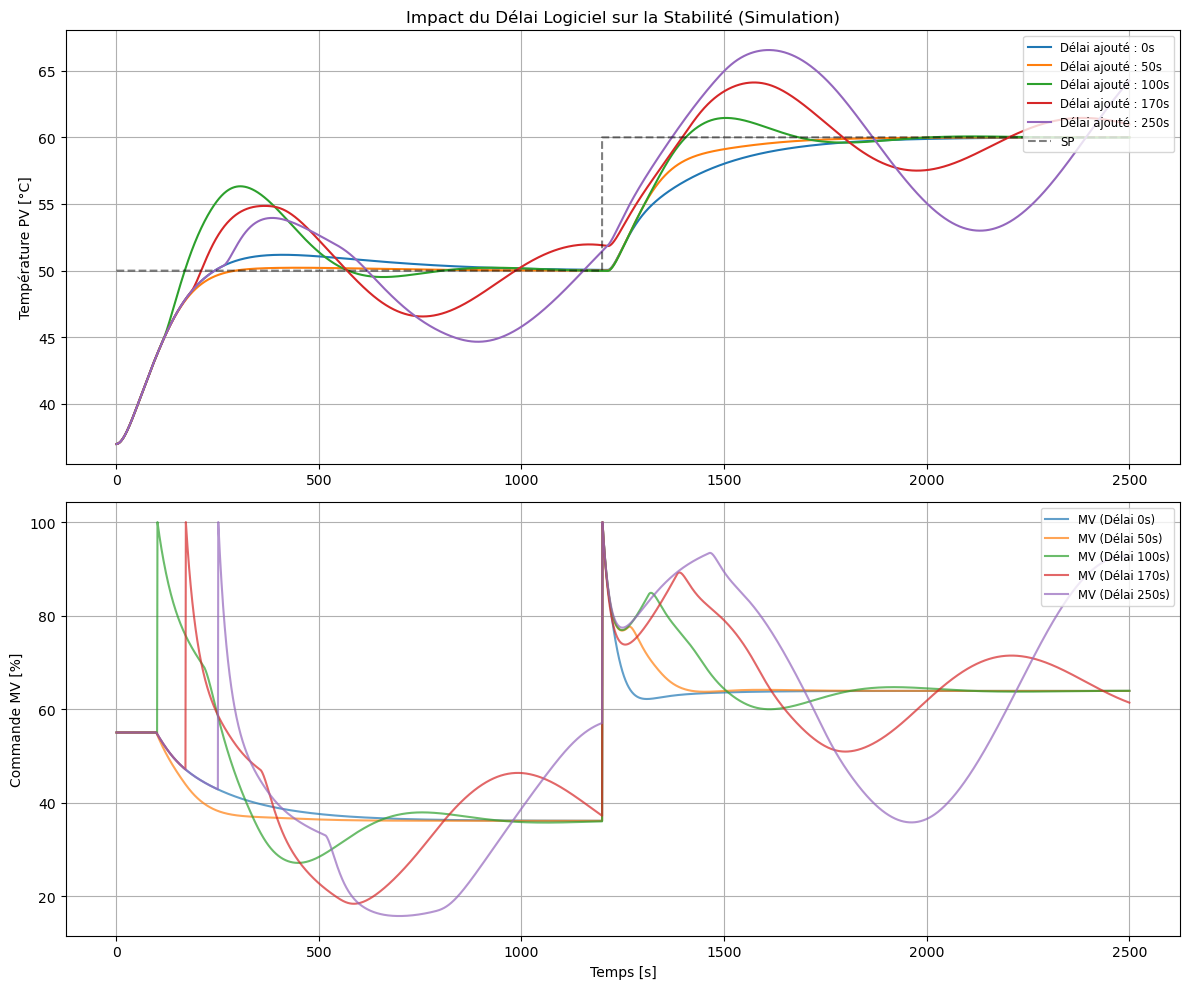

In [168]:

delais_test = [0, 50, 100, 170, 250]
alpha = 0.9
gamma = 0.9
TSim = 2500
Ts = 1 
N = int(TSim/Ts) + 1
Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2=Tp2, tauc=gamma*Tp1, model='SOPDT')

plt.figure(figsize=(12, 10))

for L_add in delais_test:
   
    t, DV, SP, Man, MVMan = [], [], [], [], []
    DV_delta, DV_delay, MVFF_step1, MVFF = [], [], [], []
    E, MV, MVP, MVI, MVD = [], [], [], [], []
    MVDelayp, PV1p, PV2p, PV = [], [], [], []
    MVDelayd, PV1d, PV2d = [], [], []

    DVPath = {0: 50, 2500: 50, TSim: 50}
    SPPath = {0: 50, 1200: 60, TSim: 60}
    ManPath = {0: True, 100: False, TSim: False}
    MVManPath = {0: 55, TSim: 55}

    for i in range(1, N):
        t.append(i * Ts)
        SelectPath_RT(DVPath, t, DV)
        SelectPath_RT(SPPath, t, SP)
        SelectPath_RT(ManPath, t, Man)
        SelectPath_RT(MVManPath, t, MVMan) 
        
        DV_delta.append(DV[-1] - DV0)
        Delay_RT(DV_delta, theta_FF, Ts, DV_delay)
        LL_RT(DV_delay, K_FF, Tp1, Td1, Ts, MVFF_step1, method='EBD')
        LL_RT(MVFF_step1, 1.0 if booléan else 0.0, Tp2, Td2, Ts, MVFF, method='EBD')
        
        if len(PV) > L_add:
            PV_delayed = [PV[-L_add-1]]
        else:
            PV_delayed = [PV[-1]] if len(PV) > 0 else [PV0]
            
        PID_RT(SP, PV_delayed, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF = booléan)

        Delay_RT(MV, thetap, Ts, MVDelayp, MV0)
        FO_RT(MVDelayp, Kp, Tp1, Ts, PV1p)
        FO_RT(PV1p, 1, Tp2, Ts, PV2p)
       
        Delay_RT(DV_delta, thetad, Ts, MVDelayd)
        FO_RT(MVDelayd, Kd, Td1, Ts, PV1d)
        FO_RT(PV1d, 1, Td2, Ts, PV2d)

        PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

    plt.subplot(2, 1, 1) 
    plt.plot(t, PV, label=f'Délai ajouté : {L_add}s')
    
    plt.subplot(2, 1, 2) 
    plt.plot(t, MV, label=f'MV (Délai {L_add}s)', alpha=0.7)

plt.subplot(2, 1, 1)
plt.step(t, SP, 'k--', label='SP', alpha=0.5)
plt.ylabel('Température PV [°C]')
plt.title('Impact du Délai Logiciel sur la Stabilité (Simulation)')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.ylabel('Commande MV [%]')
plt.xlabel('Temps [s]')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()